In [463]:
import sys, os
sys.path.append(os.path.abspath("src"))
#from src.utils.utils_import import *

import numpy as np
import pandas as pd
from bs4 import BeautifulSoup
import os, spacy, requests
from io import StringIO
from datetime import timedelta




import matplotlib.pyplot as plt


In [464]:
def save_to_csv(df, path): 
    '''
    Save DataFrame to CSV file.
    Args:
        df (pd.DataFrame): DataFrame to save.
        path (str): Path to save the CSV file.
    '''
    
    df.to_csv(path, index=False)
    
    
# =========================
# Data loaders
# =========================
def get_image_data(): 
    '''
    Scrape dataset from New Yorker caption contest website, and load and clean image metadata.
    Returns:
        pd.DataFrame: Cleaned DataFrame with image metadata.
    '''
    
    data_folder = './data/newyorker_caption_contest/'
    df = pd.read_json(data_folder + 'contests.json')
    metadata = df['metadata'].apply(pd.Series)
    df = pd.concat([df.drop(columns=['metadata']), metadata], axis=1)

    #scrape data from caption contest website
    url = "https://nextml.github.io/caption-contest-data/"
    soup = BeautifulSoup(requests.get(url).content, 'html.parser')

    df_scrape = pd.read_html(StringIO(str(soup.find('table'))))[0]


    #clean df_scrape columns
    df_scrape['Contest Dashboard'] = df_scrape['Contest Dashboard'].str.replace(' Dashboard', '').str.strip()
    df_scrape.rename(columns={'Finalists Announced (date of issue)': 'date'}, inplace=True)
    df_scrape['date'] = df_scrape['date'].str.replace(' (estimated)', '').str.strip()
    df_scrape.drop(columns=['Cartoon'], inplace=True)
    df_scrape = df_scrape.iloc[::-1].reset_index(drop=True)

    df_scrape['date'] = pd.to_datetime(df_scrape['date'], errors='coerce')
    
    # Assume contest happens each week and fill missing dates
    for i in range(1, len(df_scrape)):
        if pd.isna(df_scrape.loc[i, 'date']):
            df_scrape.loc[i, 'date'] = df_scrape.loc[i - 1, 'date'] + timedelta(days=7)

    for i in range(len(df_scrape)-2, -1, -1):
        if pd.isna(df_scrape.loc[i, 'date']):
            df_scrape.loc[i, 'date'] = df_scrape.loc[i+1, 'date'] - timedelta(days=7)

    df_scrape['Contest Dashboard'] = df_scrape['Contest Dashboard'].astype(int)
    df_complete = pd.merge(df, df_scrape, left_on='contest_id', right_on='Contest Dashboard')

    df_complete.drop(columns=['image'], inplace=True)
    df_complete.drop(columns=['data'], inplace=True)
    df_complete.drop(columns=['Contest Dashboard'], inplace=True)
    df_complete.drop(columns=['num_votes'], inplace=True) #better to keep Number of Votes from the official website

    return df_complete


def get_caption_dataset(df_image):
    '''
    Load and clean New Yorker caption contest captions.
    Args:
        df_image (pd.DataFrame): DataFrame with image metadata and website data.
    Returns:
        pd.DataFrame: Cleaned DataFrame with captions and associated metadata.
    '''
    
    path = "./data/newyorker_caption_contest/data/"
    files = [os.path.join(path,i) for i in os.listdir(path) if os.path.isfile(os.path.join(path,i)) and i.endswith('.csv')]

    df = pd.DataFrame()

    data_frames = []
    for file in files:
        
        data = pd.read_csv(file, sep=',', encoding='latin-1')
        file_number_csv =  os.path.split(file)[-1]
        file_number = int(file_number_csv.replace('.csv', ''))
        data['contest_id'] = file_number #add a column with the contest id 
        # starting from 660 the rank is no longer shown, but by comparing it with https://nextml.github.io/caption-contest-data/dashboards/883.html
        # we can assume that the order is the rank 
        if file_number >= 660: 
            data.insert(0, 'rank', np.arange(0, len(data)))
        data_frames.append(data)

    df = pd.concat(data_frames, ignore_index=True)

    # get rid of empty captions, get rid of broken captions 
    # find not complete parts   e.g 63867
    df_cleaned = df[df['caption'].notnull()] 
    df_cleaned = df_cleaned[~df_cleaned['caption'].str.contains(r'[\r\n]', regex=True)]

    df_cleaned = df_cleaned[~df_cleaned['caption'].isnull() == True]

    #join both dataframes on contest_id
    merged_df = pd.merge(df_image[["contest_id", "date"]], df_cleaned, on="contest_id", how="inner")
    
    return merged_df

In [465]:
df_image = get_image_data()
df_caption = get_caption_dataset(df_image)

# Introduction


History of the contest
The New Yorker Cartoon-caption contest started in 1998 as an annual event. In 2005 it was then changed into a weekly event.  
https://www.newyorker.com/magazine/2005/05/02/your-caption-here

explanation of the contest

The NewYorker Caption Contest is a contest run by the NewYorker Magazine that has been on for over 18 years now. In the beginning an employee was filtering the captions manually to find the highest rated.
The editorial staff then decides which one 

Who can participate? 
One entry per person, e-mail address, or Instagram account. Anyone age thirteen or over can enter, except employees, agents, or representatives of Sponsor or any other party associated with the development or administration of the Contest, or any member of their immediate family.

Submit: Every week the readers can enter a caption of 250 characters or less for a new cartoon either on the webpage (https://www.newyorker.com/cartoons/contest) or on instagram (@newyorkermag) using the hashtag #MyNewYorkerCaption. 

Rate: Rate the funniness of the captions from the previous week.

Vote: select the winning caption by voting on three finalists from the week prior

Winner: is shown the week after

sources: https://www.newyorker.com/cartoons/contest
https://www.newyorker.com/about/caption-contest-rules



In [466]:
df_image

,contest_id,num_captions,image_locations,image_descriptions,image_uncanny_descriptions,entities,questions,Top Rated caption,The New Yorker's winner,date,Number of votes
0,510,3905.0,[the street],[A man is relaxing on a city street. Others ar...,[A man is just laying in the middle of the sid...,[https://en.wikipedia.org/wiki/Bystander_effec...,[Why is he laying there?],“I'm a congressman--obstruction is my job.”,NaN,2016-03-07,82627
1,511,3325.0,"[the front hard, a residential walkway]",[A man in a winter coat and cap is looking at ...,[It's unusual to see someone holding a snow sh...,"[https://en.wikipedia.org/wiki/Snowball_fight,...",[Is the man overly small or the shovel overly ...,“I'm hourly.”,NaN,2016-03-14,56660
2,512,4399.0,"[yoga place, a yoga studio]",[A man and woman are standing facing one anoth...,[Nothing is really out of place in this image....,"[https://en.wikipedia.org/wiki/Rug, https://en...","[Why is the man carrying a huge rug?, Why is t...","“We're pretentious, not ostentatious.”",NaN,2016-03-21,43120
3,513,4141.0,"[a workplace, an elevator]",[Three business men are walking down a hall. T...,[A suit case is usually carried by one person ...,[https://en.wikipedia.org/wiki/Worker_cooperat...,[Why is the briefcase big enough for three peo...,"“I'm just saying, I can see why the 'brief'cas...",NaN,2016-03-27,34013
4,514,3951.0,[plains],[Some cowboys are riding through the desert. T...,[There are rocking horses in place of real hor...,"[https://en.wikipedia.org/wiki/Rocking_horse, ...",[Why is this chase taking place?],"“No, you grow up”",NaN,2016-04-03,192198
...,...,...,...,...,...,...,...,...,...,...,...
379,891,NaN,NaN,NaN,NaN,NaN,NaN,"“Sorry, only the catcher works from home.”",NaN,2023-08-21,928856
380,892,NaN,NaN,NaN,NaN,NaN,NaN,"“Yes, it's called Thesaurus, but you're not re...",NaN,2023-08-28,788251
381,893,NaN,NaN,NaN,NaN,NaN,NaN,“The seller isn't willing to come down.”,NaN,2023-09-04,1085745
382,894,NaN,NaN,NaN,NaN,NaN,NaN,“See how the nose seems to follow you?”,NaN,2023-09-11,878676


In [467]:
df_image.describe()

,contest_id,num_captions,date,Number of votes
count,384.000000,240.000000,384,3.840000e+02
mean,703.385417,6181.308333,2020-01-09 13:22:30,7.602295e+05
min,510.000000,2919.000000,2016-03-07 00:00:00,3.117300e+04
25%,607.750000,4764.250000,2018-03-17 06:00:00,5.660992e+05
50%,703.500000,5784.000000,2020-01-16 12:00:00,7.614170e+05
75%,799.250000,7326.250000,2021-11-16 18:00:00,9.383070e+05
max,895.000000,15329.000000,2023-09-18 00:00:00,2.249813e+06
std,111.182335,1978.687145,NaN,3.438207e+05


In [468]:
df_caption['votes'].sum()

np.int64(287757060)

In [469]:
df_caption['funny'].sum() + df_caption['somewhat_funny'].sum() + df_caption['not_funny'].sum()

np.int64(287744533)

In [470]:
df_caption.describe().apply(lambda s: s.apply('{0:.0f}'.format))

,contest_id,date,rank,mean,precision,votes,not_funny,somewhat_funny,funny
count,2263048,2263048,2263048,2263048,2263048,2263048,2263048,2263048,2263048
mean,706,.0f,3238,1,inf,127,92,25,10
min,510,.0f,0,1,0,1,0,0,0
25%,615,.0f,1485,1,0,60,51,6,1
50%,713,.0f,2984,1,0,84,69,12,2
75%,791,.0f,4604,1,0,123,97,21,6
max,895,.0f,15328,3,inf,25891,7740,9721,15232
std,106,nan,2184,0,nan,353,155,122,91


In [471]:
df_image.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 384 entries, 0 to 383
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   contest_id                  384 non-null    int64         
 1   num_captions                240 non-null    float64       
 2   image_locations             240 non-null    object        
 3   image_descriptions          240 non-null    object        
 4   image_uncanny_descriptions  240 non-null    object        
 5   entities                    240 non-null    object        
 6   questions                   240 non-null    object        
 7   Top Rated caption           384 non-null    object        
 8   The New Yorker's winner     216 non-null    object        
 9   date                        384 non-null    datetime64[ns]
 10  Number of votes             384 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(7)
memo

In [472]:
# creation of a function that returns the image and the the first x comments

# variables to change from user
NUMBER_OF_COMMENTS = 5
CONTEST = 514

#df_image[df_image['contest_id'] == CONTEST]
contest_information = df_image.loc[(df_image['contest_id'] == CONTEST)]

print(f"number of captions: {contest_information.num_captions}")
print(f"date : {contest_information.date}")
print("additional information")
print(f"image location: {contest_information.image_locations}")
print(f"image description: {contest_information.image_descriptions}")
print(f"uncanny desriptions: {contest_information.image_uncanny_descriptions}")
#print(f"top rated caption {Number of votes}")
contest_information

number of captions: 4    3951.0
Name: num_captions, dtype: float64
date : 4   2016-04-03
Name: date, dtype: datetime64[ns]
additional information
image location: 4    [plains]
Name: image_locations, dtype: object
image description: 4    [Some cowboys are riding through the desert. T...
Name: image_descriptions, dtype: object
uncanny desriptions: 4    [There are rocking horses in place of real hor...
Name: image_uncanny_descriptions, dtype: object


,contest_id,num_captions,image_locations,image_descriptions,image_uncanny_descriptions,entities,questions,Top Rated caption,The New Yorker's winner,date,Number of votes
4,514,3951.0,[plains],[Some cowboys are riding through the desert. T...,[There are rocking horses in place of real hor...,"[https://en.wikipedia.org/wiki/Rocking_horse, ...",[Why is this chase taking place?],"“No, you grow up”",NaN,2016-04-03,192198


In [473]:
captions = df_caption.loc[(df_caption['contest_id'] == CONTEST)]

captions.loc[(captions['rank'] < NUMBER_OF_COMMENTS)].drop(['contest_id', 'date', 'mean', 'precision'], axis=1)


,rank,caption,votes,not_funny,somewhat_funny,funny
15770,0,"No, you grow up",186,64,69,53
15771,1,"Sheriff, I feel like we're just going through ...",172,50,86,36
15772,2,We're losing them! They're gaining on us! We'r...,140,53,47,40
15773,3,Sometimes I feel like we're just going through...,150,47,71,32
15774,4,I think they're toying with us.,135,48,55,32


# General analysis


In [474]:
def linear_model(x, slope, intercept):
    return slope * x + intercept

In [475]:
""" # Fit a linear function (1st degree polynomial)

from scipy.optimize import curve_fit


# Convert date to a different format (using days since a specific date)
df_image['date_numeric'] = (df_image['date'] - df_image['date'].min()).dt.total_seconds() / (24 * 3600) 
#df_image = df_image.dropna()  # Drop any missing values

# Fit the model to your data
popt, pcov = curve_fit(linear_model, df_image['date_numeric'], df_image['num_captions'])

# Extract optimal parameters
slope, intercept = popt

fit_line = linear_model(df_image['date_numeric'], slope, intercept)

#df_image['rolling_num_captions'] = df_image['num_captions'].rolling(window=7).mean() #.interpolate(method='linear')

plt.figure(figsize=(16, 7))
plt.scatter(df_image['date_numeric'], df_image.num_captions, alpha=0.5)
plt.plot(df_image['date_numeric'], fit_line, color='red', label='Curve Fit')



plt.xticks(rotation=45, fontsize=11, ha="right")


plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

#change x axis :) """

' # Fit a linear function (1st degree polynomial)\n\nfrom scipy.optimize import curve_fit\n\n\n# Convert date to a different format (using days since a specific date)\ndf_image[\'date_numeric\'] = (df_image[\'date\'] - df_image[\'date\'].min()).dt.total_seconds() / (24 * 3600) \n#df_image = df_image.dropna()  # Drop any missing values\n\n# Fit the model to your data\npopt, pcov = curve_fit(linear_model, df_image[\'date_numeric\'], df_image[\'num_captions\'])\n\n# Extract optimal parameters\nslope, intercept = popt\n\nfit_line = linear_model(df_image[\'date_numeric\'], slope, intercept)\n\n#df_image[\'rolling_num_captions\'] = df_image[\'num_captions\'].rolling(window=7).mean() #.interpolate(method=\'linear\')\n\nplt.figure(figsize=(16, 7))\nplt.scatter(df_image[\'date_numeric\'], df_image.num_captions, alpha=0.5)\nplt.plot(df_image[\'date_numeric\'], fit_line, color=\'red\', label=\'Curve Fit\')\n\n\n\nplt.xticks(rotation=45, fontsize=11, ha="right")\n\n\nplt.ylabel("Frequency")\nplt.t

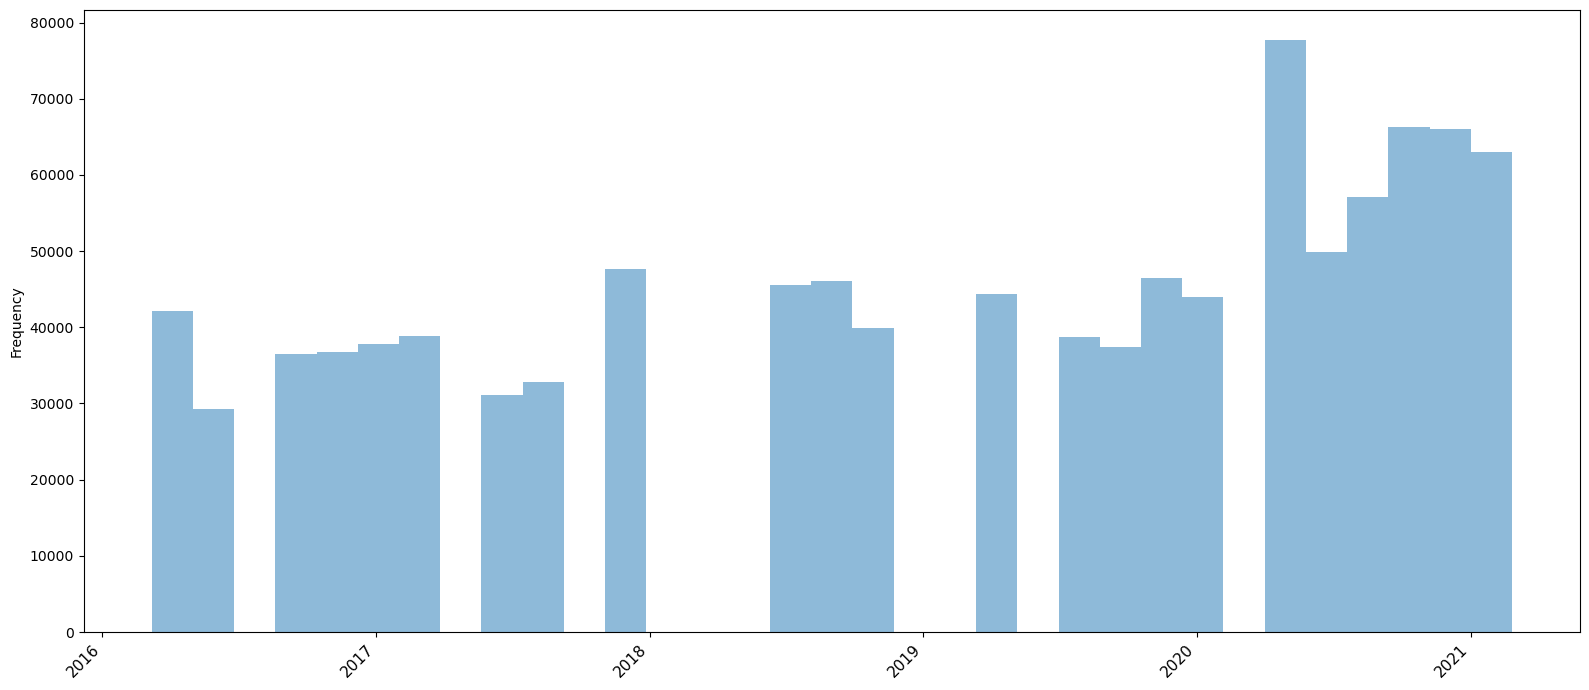

In [476]:


plt.figure(figsize=(16, 7))
#make histogram
plt.hist(df_image['date'], weights=df_image.num_captions, bins=50, alpha=0.5)
#plt.scatter(df_image['date'], df_image.num_captions, alpha=0.5)

plt.xticks(rotation=45, fontsize=11, ha="right")


plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [477]:
df_export_frequency_captions = df_image[['date', 'num_captions']].copy()
df_export_frequency_captions['date'] = df_export_frequency_captions['date'].dt.strftime('%d-%m-%Y')
df_export_frequency_captions.dropna(subset=['num_captions'], inplace=True)
#df_export_frequency_captions = df_export_frequency_captions[df_export_frequency_captions['num_captions'].notna()]
df_export_frequency_captions



,date,num_captions
0,07-03-2016,3905.0
1,14-03-2016,3325.0
2,21-03-2016,4399.0
3,27-03-2016,4141.0
4,03-04-2016,3951.0
...,...,...
247,08-02-2021,9411.0
248,15-02-2021,7393.0
249,22-02-2021,10712.0
250,01-03-2021,7076.0


In [478]:
import json


structure_json = {
    "section1": df_export_frequency_captions.to_dict(orient='records')}
with open("introduction_frequency_captions.json", "w") as json_file_vc:
    json.dump(structure_json, json_file_vc, indent=4)

from IPython.display import FileLink
FileLink("introduction_frequency_captions.json")

c:\Users\idont\Documents\ADA\ada-2025-project-data_dinosaur\introduction_frequency_captions.json

Explanation of the dataset

For each cartoon the data includes an unique contest ID, the image, a description of the image, the image location, an "uncanny" description highlighting why the scene is funny or disturbingly quirky. The dataset also contains engagement stats like the total number of captions submitted and votes received.

For every submitted caption, the dataset includes the unique contest ID, the caption's rank, total votes received, and a breakdown of funny, somewhat funny, and not funny votes.

In [479]:
df_caption

,contest_id,date,rank,caption,mean,precision,votes,not_funny,somewhat_funny,funny
0,510,2016-03-07,0,I'm a congressman--obstruction is my job.,1.913043,0.094022,69,24,27,18
1,510,2016-03-07,1,"I'm what they mean when they say, 'The middle ...",1.842105,0.191381,19,8,6,5
2,510,2016-03-07,2,Does this suit make me look flat?,1.711111,0.112915,45,21,16,8
3,510,2016-03-07,3,"When the right woman comes along, I'll know it.",1.625000,0.116657,32,15,14,3
4,510,2016-03-07,4,"I used to lie in the gutter, but then I quit d...",1.617647,0.133610,34,19,9,6
...,...,...,...,...,...,...,...,...,...,...
2263043,895,2023-09-18,4953,Looks like we took a wrong turn at the Hubble ...,1.023256,0.016347,86,84,2,0
2263044,895,2023-09-18,4954,Post-modern just doesn't do it for me.,1.022222,0.015625,90,88,2,0
2263045,895,2023-09-18,4955,How was I supposed to know they covered themse...,1.020833,0.014654,96,94,2,0
2263046,895,2023-09-18,4956,"No, they wanted us to teleport the giveaway ca...",1.020619,0.020619,97,96,0,1


In [480]:
df_caption = df_caption.merge(df_image[['contest_id', 'date']], on='contest_id', how='left')
df_caption

,contest_id,date_x,rank,caption,mean,precision,votes,not_funny,somewhat_funny,funny,date_y
0,510,2016-03-07,0,I'm a congressman--obstruction is my job.,1.913043,0.094022,69,24,27,18,2016-03-07
1,510,2016-03-07,1,"I'm what they mean when they say, 'The middle ...",1.842105,0.191381,19,8,6,5,2016-03-07
2,510,2016-03-07,2,Does this suit make me look flat?,1.711111,0.112915,45,21,16,8,2016-03-07
3,510,2016-03-07,3,"When the right woman comes along, I'll know it.",1.625000,0.116657,32,15,14,3,2016-03-07
4,510,2016-03-07,4,"I used to lie in the gutter, but then I quit d...",1.617647,0.133610,34,19,9,6,2016-03-07
...,...,...,...,...,...,...,...,...,...,...,...
2263043,895,2023-09-18,4953,Looks like we took a wrong turn at the Hubble ...,1.023256,0.016347,86,84,2,0,2023-09-18
2263044,895,2023-09-18,4954,Post-modern just doesn't do it for me.,1.022222,0.015625,90,88,2,0,2023-09-18
2263045,895,2023-09-18,4955,How was I supposed to know they covered themse...,1.020833,0.014654,96,94,2,0,2023-09-18
2263046,895,2023-09-18,4956,"No, they wanted us to teleport the giveaway ca...",1.020619,0.020619,97,96,0,1,2023-09-18


In [481]:
summary_votes = (
    df_caption
    .groupby('contest_id', as_index=False)
    .agg(
        date = ('date_x', 'first'),
        total_votes=('votes', 'sum'),
        total_captions=('contest_id', 'count'),
        total_funny=('funny', 'sum'),
        total_somewhat_funny=('somewhat_funny', 'sum'),
        total_not_funny=('not_funny', 'sum')
    )
)
summary_votes['date'] = summary_votes['date'].dt.strftime('%d-%m-%Y')

summary_votes

,contest_id,date,total_votes,total_captions,total_funny,total_somewhat_funny,total_not_funny
0,510,07-03-2016,41185,3905,709,3438,37038
1,511,14-03-2016,28205,3325,599,2950,24656
2,512,21-03-2016,21574,4399,609,2416,18549
3,513,27-03-2016,16894,4141,657,2424,13813
4,514,03-04-2016,95790,3951,7639,22267,65884
...,...,...,...,...,...,...,...
379,891,21-08-2023,928735,5158,50679,165114,712942
380,892,28-08-2023,788251,5188,50492,141107,596652
381,893,04-09-2023,1085745,5513,83768,215129,786848
382,894,11-09-2023,878676,6157,44343,128594,705740


In [482]:
top_three = summary_votes.nlargest(3, 'total_captions')
print(top_three)

     contest_id        date  total_votes  total_captions  total_funny  \
204         716  13-04-2020       259088           15147        11781   
232         744  26-10-2020      1091840           12148        59903   
228         740  28-09-2020      1006065           10934        86596   

     total_somewhat_funny  total_not_funny  
204                 39237           208070  
232                196543           835395  
228                230840           688596  


In [483]:
summary_votes[summary_votes['total_captions'] == summary_votes['total_captions'].max()]

,contest_id,date,total_votes,total_captions,total_funny,total_somewhat_funny,total_not_funny
204,716,13-04-2020,259088,15147,11781,39237,208070


In [484]:
summary_votes.describe().apply(lambda s: s.apply('{0:.0f}'.format))

,contest_id,total_votes,total_captions,total_funny,total_somewhat_funny,total_not_funny
count,384,384,384,384,384,384
mean,703,749367,5893,59962,147377,541996
std,111,341770,1751,39882,81207,240120
min,510,16894,1052,4,1964,13813
25%,608,558457,4645,33443,93163,423958
50%,704,751493,5588,53629,145615,548008
75%,799,928229,6825,78173,194649,662273
max,895,2210972,15147,263727,432364,1703970


In [485]:
summary_votes[summary_votes['total_votes'] == summary_votes['total_votes'].max()]

,contest_id,date,total_votes,total_captions,total_funny,total_somewhat_funny,total_not_funny
139,651,14-01-2019,2210972,9089,125636,381366,1703970


In [486]:
summary_votes[summary_votes['total_votes'] == summary_votes['total_votes'].min()]

,contest_id,date,total_votes,total_captions,total_funny,total_somewhat_funny,total_not_funny
3,513,27-03-2016,16894,4141,657,2424,13813


In [487]:
summary_votes[summary_votes['total_funny'] == summary_votes['total_funny'].max()]

,contest_id,date,total_votes,total_captions,total_funny,total_somewhat_funny,total_not_funny
206,718,27-04-2020,1906570,9023,263727,427402,1215439


In [488]:
structure_json = {
    "section1": summary_votes.to_dict(orient='records')}
with open("summary_votes.json", "w") as json_file_vc:
    json.dump(structure_json, json_file_vc, indent=4)

FileLink("summary_votes.json")

c:\Users\idont\Documents\ADA\ada-2025-project-data_dinosaur\summary_votes.json

In [491]:
df_image.rename(columns={"Number of votes": "number_of_votes"})


,contest_id,num_captions,image_locations,image_descriptions,image_uncanny_descriptions,entities,questions,Top Rated caption,The New Yorker's winner,date,number_of_votes
0,510,3905.0,[the street],[A man is relaxing on a city street. Others ar...,[A man is just laying in the middle of the sid...,[https://en.wikipedia.org/wiki/Bystander_effec...,[Why is he laying there?],“I'm a congressman--obstruction is my job.”,NaN,2016-03-07,82627
1,511,3325.0,"[the front hard, a residential walkway]",[A man in a winter coat and cap is looking at ...,[It's unusual to see someone holding a snow sh...,"[https://en.wikipedia.org/wiki/Snowball_fight,...",[Is the man overly small or the shovel overly ...,“I'm hourly.”,NaN,2016-03-14,56660
2,512,4399.0,"[yoga place, a yoga studio]",[A man and woman are standing facing one anoth...,[Nothing is really out of place in this image....,"[https://en.wikipedia.org/wiki/Rug, https://en...","[Why is the man carrying a huge rug?, Why is t...","“We're pretentious, not ostentatious.”",NaN,2016-03-21,43120
3,513,4141.0,"[a workplace, an elevator]",[Three business men are walking down a hall. T...,[A suit case is usually carried by one person ...,[https://en.wikipedia.org/wiki/Worker_cooperat...,[Why is the briefcase big enough for three peo...,"“I'm just saying, I can see why the 'brief'cas...",NaN,2016-03-27,34013
4,514,3951.0,[plains],[Some cowboys are riding through the desert. T...,[There are rocking horses in place of real hor...,"[https://en.wikipedia.org/wiki/Rocking_horse, ...",[Why is this chase taking place?],"“No, you grow up”",NaN,2016-04-03,192198
...,...,...,...,...,...,...,...,...,...,...,...
379,891,NaN,NaN,NaN,NaN,NaN,NaN,"“Sorry, only the catcher works from home.”",NaN,2023-08-21,928856
380,892,NaN,NaN,NaN,NaN,NaN,NaN,"“Yes, it's called Thesaurus, but you're not re...",NaN,2023-08-28,788251
381,893,NaN,NaN,NaN,NaN,NaN,NaN,“The seller isn't willing to come down.”,NaN,2023-09-04,1085745
382,894,NaN,NaN,NaN,NaN,NaN,NaN,“See how the nose seems to follow you?”,NaN,2023-09-11,878676


In [490]:
#average number of votes
print(f"average number of votes {df_image['number_of_votes'].mean()}")
#average number of captions
print(f"average number of captions: {df_image['num_captions'].mean()}")
print(f"average number of images: {df_image['contest_id'].count()}")

KeyError: 'number_of_votes'

In [ ]:
print(f"number of votes {df_image['number_of_votes'].sum()}")
#average number of captions
print(f"number of captions: {df_image['num_captions'].sum()}")

In [ ]:
# Filter for rank = 0
rank_0_votes = df_caption[df_caption['rank'] == 0]

# Calculate the average votes
average_votes = rank_0_votes['votes'].mean()

# Print the result
print(f'Average Votes for Rank = 0: {average_votes}')

